<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_02_pandas_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# PRIMERO: Ejecuta esta celda para forzar la instalación de versiones compatibles
!pip uninstall numpy scipy statsmodels fitter -y
!pip install numpy==1.24.3
!pip install scipy==1.10.1
!pip install statsmodels
!pip install fitter

# Después de ejecutar esto, ve a Runtime → Restart runtime
print("✅ Versiones instaladas. AHORA ve a Runtime → Restart runtime y luego ejecuta la siguiente celda")

Found existing installation: numpy 2.4.3
Uninstalling numpy-2.4.3:
  Successfully uninstalled numpy-2.4.3
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: statsmodels 0.14.6
Uninstalling statsmodels-0.14.6:
  Successfully uninstalled statsmodels-0.14.6
  Using cached numpy-1.24.3.tar.gz (10.9 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
ERROR: Ignored the following yanked versions: 1.11.0, 

  Using cached fitter-1.8.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached rich_click-1.9.7-py3-none-any.whl.metadata (8.7 kB)
Using cached fitter-1.8.0-py3-none-any.whl (30 kB)
Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
Using cached rich_click-1.9.7-py3-none-any.whl (71 kB)
^C
✅ Versiones instaladas. AHORA ve a Runtime → Restart runtime y luego ejecuta la siguiente celda


In [1]:
!pip install fitter #Agregado porque sino no corre por compatibiidad con versiones de numpy

  Using cached fitter-1.8.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached rich_click-1.9.7-py3-none-any.whl.metadata (8.7 kB)
Using cached fitter-1.8.0-py3-none-any.whl (30 kB)
Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
Using cached rich_click-1.9.7-py3-none-any.whl (71 kB)
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-co

In [ ]:
!pip install ucimlrepo seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fitter import Fitter
from scipy import stats
import scipy
import seaborn as sns
import re
from ucimlrepo import fetch_ucirepo



# Lab 2: Estadística Descriptiva Básica 2

## Series de tiempo

El siguiente [dataset](https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv) contiene información del precio del eur/usd  desde el 05/07/2022/ hasta el 12/05/2023 con periodicidad de una hora. El data frame contiene el precio de apertura, cierrre, valor más bajo cotizado, valor más alto cotizado, volumen, spread etc. Para este dataset, realizar lo siguiente:


1. Leer el dataset desde el github.
2. Definir como indice la columna time.
3. Obtenga información del data frame.

4. Determine si hay null, nan en el data frame.

5. Emplea la notacion Pascal Case y trabaja solo con la columa del precio de cierre del eur/usd.  

6. Ahora vamos a determinar cual es la mejor distribución estadística que se ajusta a la diferencia del precio de cierre cada hora, para ello realizamos lo siguiente:
- Determine la diferencia de precio entre horas, agregue una nueva columna llamada DiffPrice, en este punto tu dataframe debe tener solo dos columnas Close, DiffPrice y el indice debe ser el tiempo.
- Para la nueva columna construya un histograma de los datos.
- Determine la mejor distribucion estadística que se ajusta al histograma anterior, para ello puede emplear lo siguente:


https://pypi.org/project/fitter/

```python


from fitter import Fitter, get_common_distributions, get_distributions

f = Fitter(data,
           distributions=['gamma',
                          'lognorm',
                          "beta",
                          "burr",
                          "norm"])
f.fit()
f.summary()
#Indentificamos la mejor distribucion con el error cuadratico medio
f.get_best(method = 'sumsquare_error')
#Indentificamos parametros de la distrubicion beta
f.fitted_param["beta"]

```

Con el metodo get_distributions(), podemos ver todas las distribuciones estadisticas de la libreria. Ajusta a la mejor.  Puede consultar [esta](https://medium.com/the-researchers-guide/finding-the-best-distribution-that-fits-your-data-using-pythons-fitter-library-319a5a0972e9)  página si desea ver un ejemplo.


7. Para el data frame, seleccionemos solo los datos del 2023.

8. El comando groupby permite agrupar los datos con la periodicidad deseada: 1 dias, 2 dias, 1 mes etc. Determina el promedio con una periodicidad de 15 dias, con periodidicidad de 1 semana, y una periodicidad de 1 mes

```python
  df.groupby(pd.Grouper(key='time', freq='15D')).mean()
```

9. Para los datos asociados a los meses de 2023, construya un histograma para cada mes.  Para ello puedo emplear el metodo groupby. Notetese que si no  realiza una operación después de aplicar el metodo grouby, podrias iterar sobre dicho objeto, por ejemplo:

```python
q=df.groupby(pd.Grouper(key='time', freq='15D'))

for name, group in q:
  print(name, group)
```


## Análisis de datos con pandas.

Para el siguiente [dataset](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29) realizar lo siguiente:


1. Leer los datos desde una página web.

2. Renombrar las columnas en formato PascalCase.

3. Utilizar los métodos `head()`, `tail()`, `describe()` e `info()` para obtener información sobre el `DataFrame`.

4. Contabilizar la cantidad de valores nulos (`null` o `NaN`) en el `DataFrame`.
   Si se encuentran valores nulos, ¿qué estrategia propondrías para reemplazarlos?

5. Identificar los valores únicos en la columna `target` que representan las etiquetas B y M (Benigno y Maligno, respectivamente).
   Utiliza el método `unique()` para mostrar estos valores.

6. Realizar un conteo de los casos etiquetados como B y M utilizando la librería `seaborn` y el método `countplot()`:

```python
import seaborn as sns
sns.countplot?
```

7. Agregar una nueva columna llamada `DiagnosisNumeric` donde se asigna el valor 0 a la etiqueta B (Benigno) y el valor 1 a la etiqueta M (Maligno).


8. Normalizar cada columna respecto a su media y desviación estándar utilizando la fórmula:  
   `(x - mean(x)) / std(x)`

9. Agrupar características similares y calcular su promedio.
   Para las siguientes características:

```python
['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"]
```

Usa expresiones regulares para identificar patrones comunes, como `radius1`, `radius2`,`radius3`, etc., y calcular los promedios. Por ejemplo:

```python
re.match(r'^[a-zA-Z_]+', "holamundo12341").group(0)
```

También puedes utilizar el método `startswith()` para buscar estos patrones en los nombres de las columnas.


10. Crear un gráfico donde se muestre el histograma de la columna `RadiusMean` separado por las etiquetas B y M, utilizando colores diferentes (naranja y azul, respectivamente) para cada diagnóstico.

11. Generar gráficos de violín para múltiples características.
   Para las columnas:

   - `RadiusMean`
   - `TextureMean`
   - `PerimeterMean`
   - `AreaMean`
   - `SmoothnessMean`
   - `CompactnessMean`
   - `ConcavityMean`
   - `ConcavePointsMean`
   - `Symmetry3`
   - `FractalDimension3`

   Realiza un gráfico múltiple tipo violín, como en el siguiente ejemplo:

```python
data = pd.melt(df.iloc[:, 0:10], id_vars="Diagnosis", var_name="features", value_name="value")
sns.violinplot(x="features", y="value", hue="Diagnosis", data=data, split=True, inner="quart")
plt.xticks(rotation=45)
```


12.  Determinar y eliminar los valores atípicos (`outliers`) en la columna `RadiusMean`.

Para identificarlos, construye un gráfico tipo `boxplot`:

```python
df.boxplot(column="RadiusMean", by='Diagnosis', sym='k.', figsize=(18,6))
```

Usa el rango intercuartílico (IQR) para definir los outliers. Los valores fuera del rango [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR] se consideran outliers. Ejemplo de cómo eliminar estos valores:

```python
Q1 = df['edad'].quantile(0.25)
Q3 = df['edad'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['edad'] < (Q1 - 1.5 * IQR)) | (df['edad'] > (Q3 + 1.5 * IQR)))]
```

Otra alternativa es utilizar el puntaje Z para detectar `outliers`:

```python
df = df[(np.abs(stats.zscore(df['edad'])) < 3)]
```



13. Encontrar la matrix de correlación, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.

14. ¿Que otro tipo de gráficos pueden ser realizados para entender mejor los datos?



In [1]:

# URL del dataset en GitHub
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv"

# Leer el dataset
df = pd.read_csv(url, index_col=0)

# Verificar que se cargó correctamente
print("Primeras 5 filas del dataset:")
print(df.head())

print("Últimas 5 filas del dataset:")
print(df.tail())

print("\nInformación del dataset:")
print(df.info())

print("\nEstadísticas descriptivas:")
print(df.describe())

Primeras 5 filas del dataset:
                  time     open     high      low    close  tick_volume  \
0  2022-07-25 13:00:00  1.02427  1.02430  1.02145  1.02345         3927   
1  2022-07-25 14:00:00  1.02345  1.02578  1.02288  1.02299         5344   
2  2022-07-25 15:00:00  1.02303  1.02476  1.02230  1.02457         5524   
3  2022-07-25 16:00:00  1.02454  1.02548  1.02355  1.02485         5234   
4  2022-07-25 17:00:00  1.02485  1.02514  1.02030  1.02181         9031   

   spread  real_volume  MeanCloseOpen  Diff_Close  Diff_Open  \
0       8            0       1.023860    -0.00046   -0.00082   
1       8            0       1.023220    -0.00046   -0.00082   
2       8            0       1.023800     0.00158   -0.00042   
3       8            0       1.024695     0.00028    0.00151   
4       7            0       1.023330    -0.00304    0.00031   

   Diff_MeanCloseOpen  
0           -0.000640  
1           -0.000640  
2            0.000580  
3            0.000895  
4           -0

In [2]:


# URL del dataset en GitHub
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv"

# Leer el dataset
df = pd.read_csv(url)

# 1. Definir como índice la columna time
df['time'] = pd.to_datetime(df['time'])  # Convertir a datetime
df.set_index('time', inplace=True)

# 2. Obtener información del dataframe
print("="*50)
print("INFORMACIÓN DEL DATAFRAME")
print("="*50)
print("\n--- Información general (info()) ---")
print(df.info())

print("\n--- Descripción estadística (describe()) ---")
print(df.describe())

print("\n--- Forma del dataframe (filas, columnas) ---")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\n--- Columnas disponibles ---")
print(df.columns.tolist())

print("\n--- Tipos de datos ---")
print(df.dtypes)

# 3. Determinar si hay null, nan en el dataframe
print("\n" + "="*50)
print("VALORES NULOS Y NaN")
print("="*50)

# Verificar valores nulos por columna
print("\n--- Valores nulos por columna ---")
null_counts = df.isnull().sum()
print(null_counts)

# Verificar si hay algún valor nulo en todo el dataframe
print("\n--- ¿Hay algún valor nulo en el dataframe? ---")
print(df.isnull().any().any())

# Porcentaje de valores nulos por columna
print("\n--- Porcentaje de valores nulos por columna ---")
null_percentage = (df.isnull().sum() / len(df)) * 100
print(null_percentage)

# Verificar el rango del índice (debe ir hasta ~5000)
print("\n" + "="*50)
print("INFORMACIÓN DEL ÍNDICE")
print("="*50)
print(f"Rango del índice: {df.index[0]} a {df.index[-1]}")
print(f"Número total de registros: {len(df)}")

INFORMACIÓN DEL DATAFRAME

--- Información general (info()) ---
<class 'pandas.DataFrame'>
DatetimeIndex: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5000 non-null   int64  
 1   open                5000 non-null   float64
 2   high                5000 non-null   float64
 3   low                 5000 non-null   float64
 4   close               5000 non-null   float64
 5   tick_volume         5000 non-null   int64  
 6   spread              5000 non-null   int64  
 7   real_volume         5000 non-null   int64  
 8   MeanCloseOpen       5000 non-null   float64
 9   Diff_Close          5000 non-null   float64
 10  Diff_Open           5000 non-null   float64
 11  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 507.8 KB
None

--- Descripción estadística (describe()) ---
        Unnamed

INFORMACIÓN DEL DATAFRAME
<class 'pandas.DataFrame'>
DatetimeIndex: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5000 non-null   int64  
 1   open                5000 non-null   float64
 2   high                5000 non-null   float64
 3   low                 5000 non-null   float64
 4   close               5000 non-null   float64
 5   tick_volume         5000 non-null   int64  
 6   spread              5000 non-null   int64  
 7   real_volume         5000 non-null   int64  
 8   MeanCloseOpen       5000 non-null   float64
 9   Diff_Close          5000 non-null   float64
 10  Diff_Open           5000 non-null   float64
 11  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 507.8 KB
None

¿Hay valores nulos? False

DATAFRAME PASCAL CASE (SOLO CLOSE)
                       Close
Time   

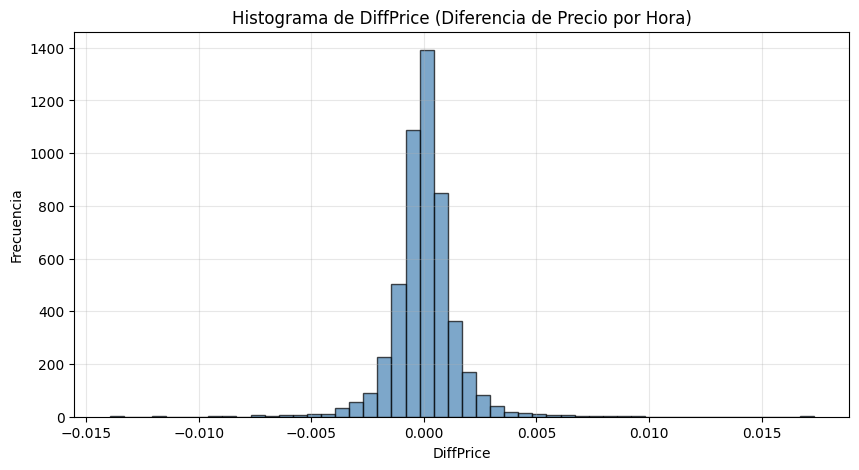


ANÁLISIS CON FITTER

📊 Top 5 distribuciones (mejor por suma de errores cuadrados):

🏆 MEJOR DISTRIBUCIÓN: laplace
   Parámetros: (np.float64(0.0), np.float64(0.0009126245249049809))


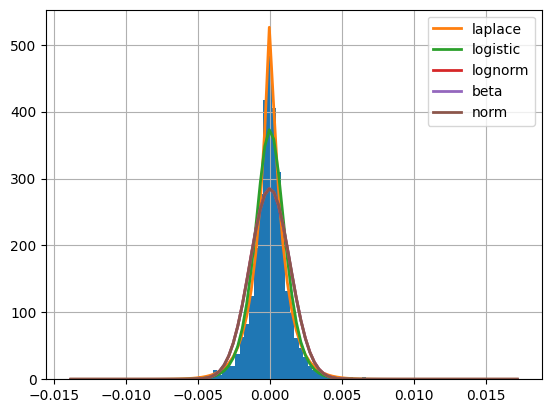

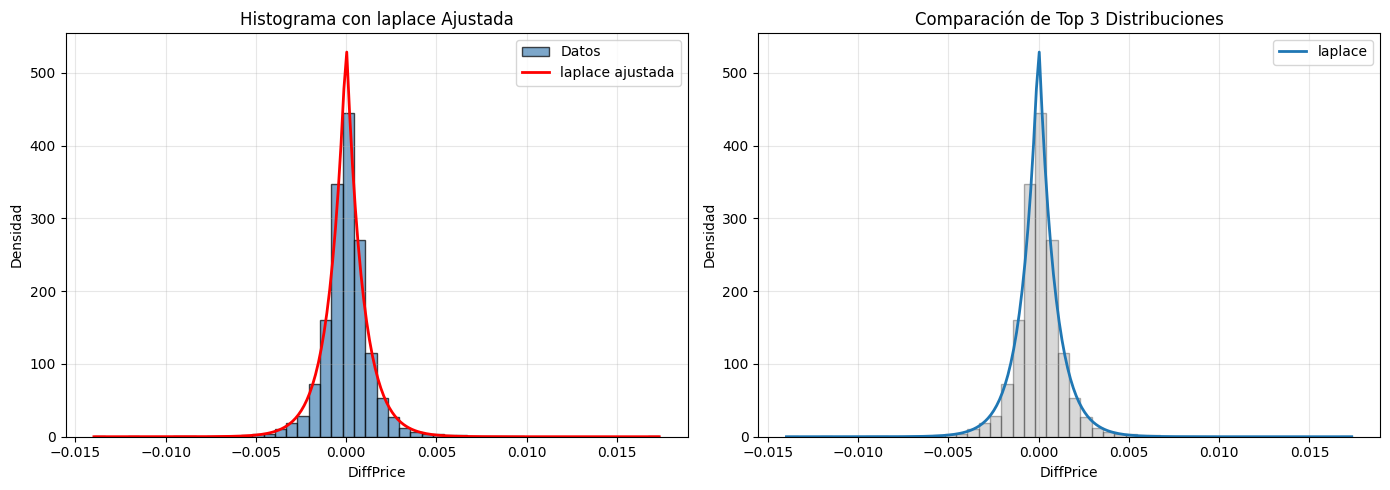


DATOS 2023
Años disponibles: [2022, 2023]
✅ Datos de 2023: 2278 registros
Rango: 2023-01-02 00:00:00 a 2023-05-12 23:00:00

PROMEDIOS

📅 Promedio cada 15 días:
               Close  DiffPrice
Time                           
2023-01-02  1.069361   0.000047
2023-01-17  1.085565   0.000015
2023-02-01  1.077679  -0.000066
2023-02-16  1.063150  -0.000034
2023-03-03  1.063186   0.000026
2023-03-18  1.080936   0.000074
2023-04-02  1.093090   0.000063
2023-04-17  1.099084  -0.000006
2023-05-02  1.098889  -0.000059

📅 Promedio semanal:
               Close  DiffPrice
Time                           
2023-01-08  1.059972  -0.000047
2023-01-15  1.076002   0.000156
2023-01-22  1.082041   0.000020
2023-01-29  1.088414   0.000010
2023-02-05  1.089281  -0.000062
2023-02-12  1.073363  -0.000097
2023-02-19  1.069648   0.000014
2023-02-26  1.063374  -0.000124
2023-03-05  1.060854   0.000073
2023-03-12  1.060234   0.000004
2023-03-19  1.066518   0.000022
2023-03-26  1.077974   0.000079
2023-04-02  1.0838

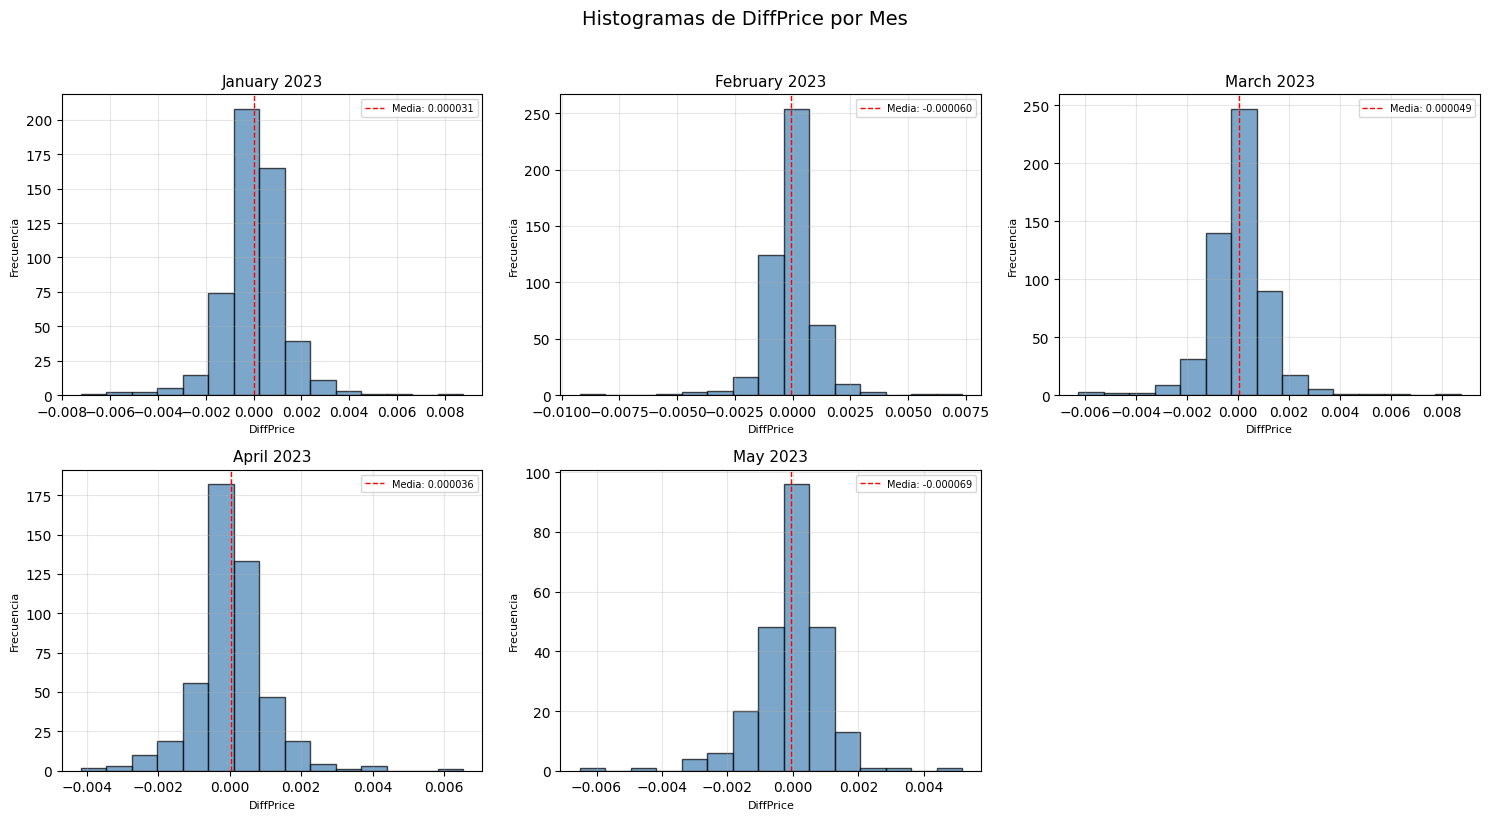


📊 Estadísticas mensuales:
    Mes     Media      Std      Min     Max
2023-01  0.000031 0.001320 -0.00723 0.00877
2023-02 -0.000060 0.001148 -0.00923 0.00735
2023-03  0.000049 0.001213 -0.00626 0.00873
2023-04  0.000036 0.001021 -0.00417 0.00654
2023-05 -0.000069 0.001115 -0.00652 0.00517

✅ ANÁLISIS COMPLETADO
🎯 Mejor distribución encontrada: laplace


In [3]:

# Definir time como índice
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

# Pascal Case - DataFrame solo con Close
class EurUsdData:
    def __init__(self, df):
        self.ClosePrice = df['close']
        self.TimeIndex = df.index

# Crear dataframe con Pascal Case
data = EurUsdData(df)
df_close = pd.DataFrame({
    'Close': data.ClosePrice
}, index=data.TimeIndex)
df_close.index.name = 'Time'

print("\n" + "="*50)
print("DATAFRAME PASCAL CASE (SOLO CLOSE)")
print("="*50)
print(df_close.head())

# Calcular diferencia de precio
df_close['DiffPrice'] = df_close['Close'].diff()
df_diff = df_close.dropna().copy()

print("\n" + "="*50)
print("DATAFRAME CON DiffPrice")
print("="*50)
print(df_diff.head())

# Histograma básico
plt.figure(figsize=(10, 5))
plt.hist(df_diff['DiffPrice'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Histograma de DiffPrice (Diferencia de Precio por Hora)')
plt.xlabel('DiffPrice')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.show()

# FITTER - Encontrar mejor distribución
print("\n" + "="*50)
print("ANÁLISIS CON FITTER")
print("="*50)

# Preparar datos
data_fitter = df_diff['DiffPrice'].values

# Distribuciones a probar
distribuciones = ['norm', 'gamma', 'expon', 'lognorm', 'beta', 'laplace', 'logistic']

# Crear y ajustar fitter
f = Fitter(data_fitter, distributions=distribuciones)
f.fit()

# Mostrar resumen
print("\n📊 Top 5 distribuciones (mejor por suma de errores cuadrados):")
f.summary()

# Obtener la mejor distribución
best_dist = f.get_best(method='sumsquare_error')
best_name = list(best_dist.keys())[0]
print(f"\n🏆 MEJOR DISTRIBUCIÓN: {best_name}")
print(f"   Parámetros: {f.fitted_param[best_name]}")

# Gráfico de la mejor distribución
plt.figure(figsize=(14, 5))

# Histograma de los datos originales
plt.subplot(1, 2, 1)
plt.hist(data_fitter, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black', label='Datos')


# Mapeo de nombres de distribución a objetos scipy
dist_map = {
    'norm': scipy.stats.norm,
    'gamma': scipy.stats.gamma,
    'expon': scipy.stats.expon,
    'lognorm': scipy.stats.lognorm,
    'beta': scipy.stats.beta,
    'laplace': scipy.stats.laplace,
    'logistic': scipy.stats.logistic
}

# Obtener la distribución y sus parámetros
best_dist_obj = dist_map[best_name]
params = f.fitted_param[best_name]

# Generar puntos para la curva
x = np.linspace(data_fitter.min(), data_fitter.max(), 200)
y = best_dist_obj.pdf(x, *params)

plt.plot(x, y, 'r-', lw=2, label=f'{best_name} ajustada')
plt.title(f'Histograma con {best_name} Ajustada')
plt.xlabel('DiffPrice')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)

# Comparación de distribuciones
plt.subplot(1, 2, 2)
# Obtener las 3 mejores distribuciones
best_names = list(best_dist.keys())[:3]
for name in best_names:
    dist_obj = dist_map[name]
    params = f.fitted_param[name]
    y = dist_obj.pdf(x, *params)
    plt.plot(x, y, lw=2, label=f'{name}')

plt.hist(data_fitter, bins=50, density=True, alpha=0.3, color='gray', edgecolor='black')
plt.title('Comparación de Top 3 Distribuciones')
plt.xlabel('DiffPrice')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Datos del 2023
print("\n" + "="*50)
print("DATOS 2023")
print("="*50)

# Verificar años disponibles
años = df_diff.index.year.unique()
print(f"Años disponibles: {sorted(años)}")

if 2023 in años:
    df_2023 = df_diff[df_diff.index.year == 2023].copy()
    print(f"✅ Datos de 2023: {len(df_2023)} registros")
else:
    año_reciente = max(años)
    df_2023 = df_diff[df_diff.index.year == año_reciente].copy()
    print(f"⚠️ No hay datos 2023. Usando {año_reciente}: {len(df_2023)} registros")

print(f"Rango: {df_2023.index.min()} a {df_2023.index.max()}")

# 9. Promedios con groupby
print("\n" + "="*50)
print("PROMEDIOS")
print("="*50)

print("\n📅 Promedio cada 15 días:")
print(df_2023.groupby(pd.Grouper(freq='15D')).mean().round(6))

print("\n📅 Promedio semanal:")
print(df_2023.groupby(pd.Grouper(freq='W')).mean().round(6))

print("\n📅 Promedio mensual:")
print(df_2023.groupby(pd.Grouper(freq='ME')).mean().round(6))

# 10. Histogramas por mes
print("\n" + "="*50)
print("HISTOGRAMAS POR MES")
print("="*50)

# Agrupar por mes
grupos_mensuales = list(df_2023.groupby(pd.Grouper(freq='ME')))
meses_con_datos = [(fecha, grupo) for fecha, grupo in grupos_mensuales if len(grupo) > 0]

if meses_con_datos:
    n_meses = len(meses_con_datos)
    n_cols = 3
    n_rows = (n_meses + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_meses > 1 else [axes]

    stats_mensuales = []

    for idx, (fecha, grupo) in enumerate(meses_con_datos):
        if idx < len(axes):
            datos_mes = grupo['DiffPrice'].dropna()

            axes[idx].hist(datos_mes, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
            axes[idx].axvline(datos_mes.mean(), color='red', linestyle='--',
                             linewidth=1, label=f"Media: {datos_mes.mean():.6f}")
            axes[idx].set_title(fecha.strftime('%B %Y'), fontsize=11)
            axes[idx].set_xlabel('DiffPrice', fontsize=8)
            axes[idx].set_ylabel('Frecuencia', fontsize=8)
            axes[idx].legend(fontsize=7)
            axes[idx].grid(True, alpha=0.3)

            stats_mensuales.append({
                'Mes': fecha.strftime('%Y-%m'),
                'Media': datos_mes.mean(),
                'Std': datos_mes.std(),
                'Min': datos_mes.min(),
                'Max': datos_mes.max()
            })

    # Ocultar ejes vacíos
    for idx in range(n_meses, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Histogramas de DiffPrice por Mes', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Mostrar estadísticas
    if stats_mensuales:
        print("\n📊 Estadísticas mensuales:")
        stats_df = pd.DataFrame(stats_mensuales)
        print(stats_df.round(6).to_string(index=False))
else:
    print("No hay datos suficientes para histogramas mensuales")

print("\n" + "="*50)
print("✅ ANÁLISIS COMPLETADO")
print(f"🎯 Mejor distribución encontrada: {best_name}")
print("="*50)

  Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
ANÁLISIS DE DATOS - BREAST CANCER WISCONSIN

📥 1. CARGANDO DATOS...
--------------------------------------------------
✅ Datos cargados correctamente
   Dimensiones: (569, 31)
   Filas: 569, Columnas: 31

📝 2. RENOMBRANDO COLUMNAS A PASCALCASE...
----

/tmp/ipykernel_3002/1404662562.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Diagnosis', palette=['#3498db', '#e74c3c'])


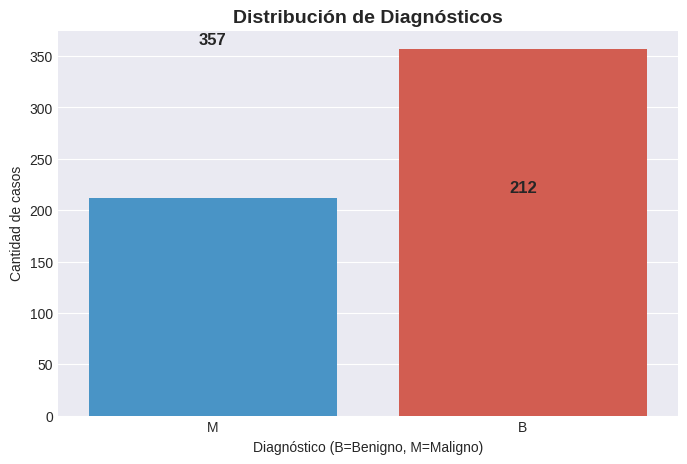

Benignos (B): 357
Malignos (M): 212

🔢 7. CREANDO COLUMNA DiagnosisNumeric
--------------------------------------------------
Primeras 5 filas con DiagnosisNumeric:
  Diagnosis  DiagnosisNumeric
0         M                 1
1         M                 1
2         M                 1
3         M                 1
4         M                 1

📈 8. NORMALIZACIÓN DE CARACTERÍSTICAS
--------------------------------------------------
Normalizando 30 características...
  ✓ Radius1 → Radius1_Normalized
  ✓ Texture1 → Texture1_Normalized
  ✓ Perimeter1 → Perimeter1_Normalized
  ✓ Area1 → Area1_Normalized
  ✓ Smoothness1 → Smoothness1_Normalized
  ✓ Compactness1 → Compactness1_Normalized
  ✓ Concavity1 → Concavity1_Normalized
  ✓ ConcavePoints1 → ConcavePoints1_Normalized
  ✓ Symmetry1 → Symmetry1_Normalized
  ✓ FractalDimension1 → FractalDimension1_Normalized
  ✓ Radius2 → Radius2_Normalized
  ✓ Texture2 → Texture2_Normalized
  ✓ Perimeter2 → Perimeter2_Normalized
  ✓ Area2 → Area2_Normalize

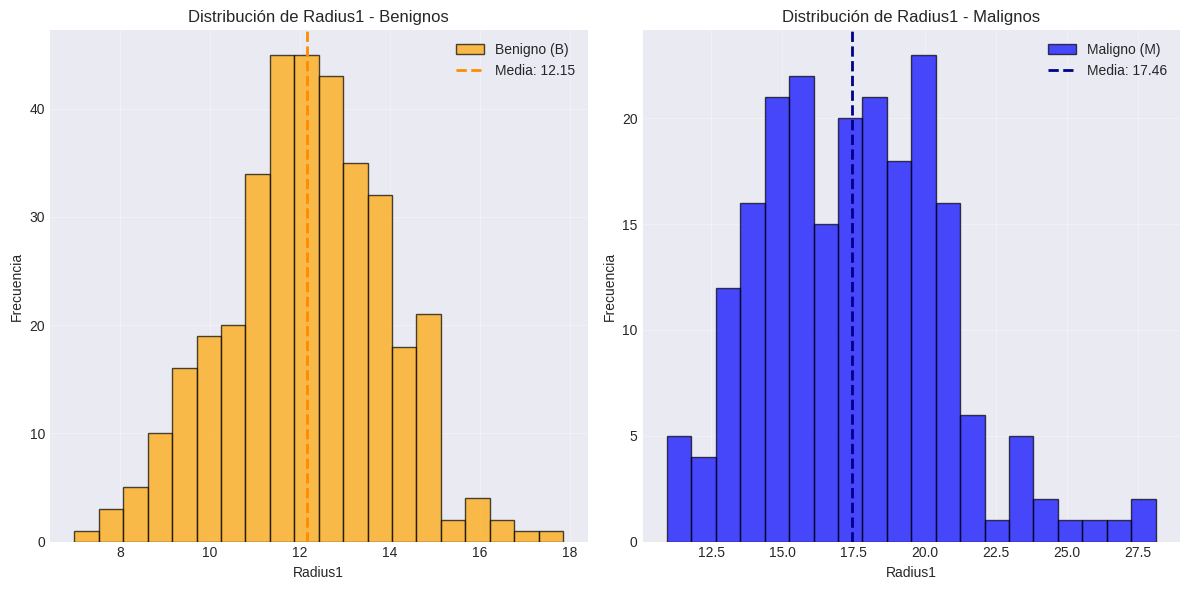


📊 Estadísticas comparativas de Radius1:
Benignos  - Media: 12.1465, Std: 1.7805
Malignos  - Media: 17.4628, Std: 3.2040

🎻 11. GRÁFICOS DE VIOLÍN PARA CARACTERÍSTICAS IMPORTANTES
--------------------------------------------------


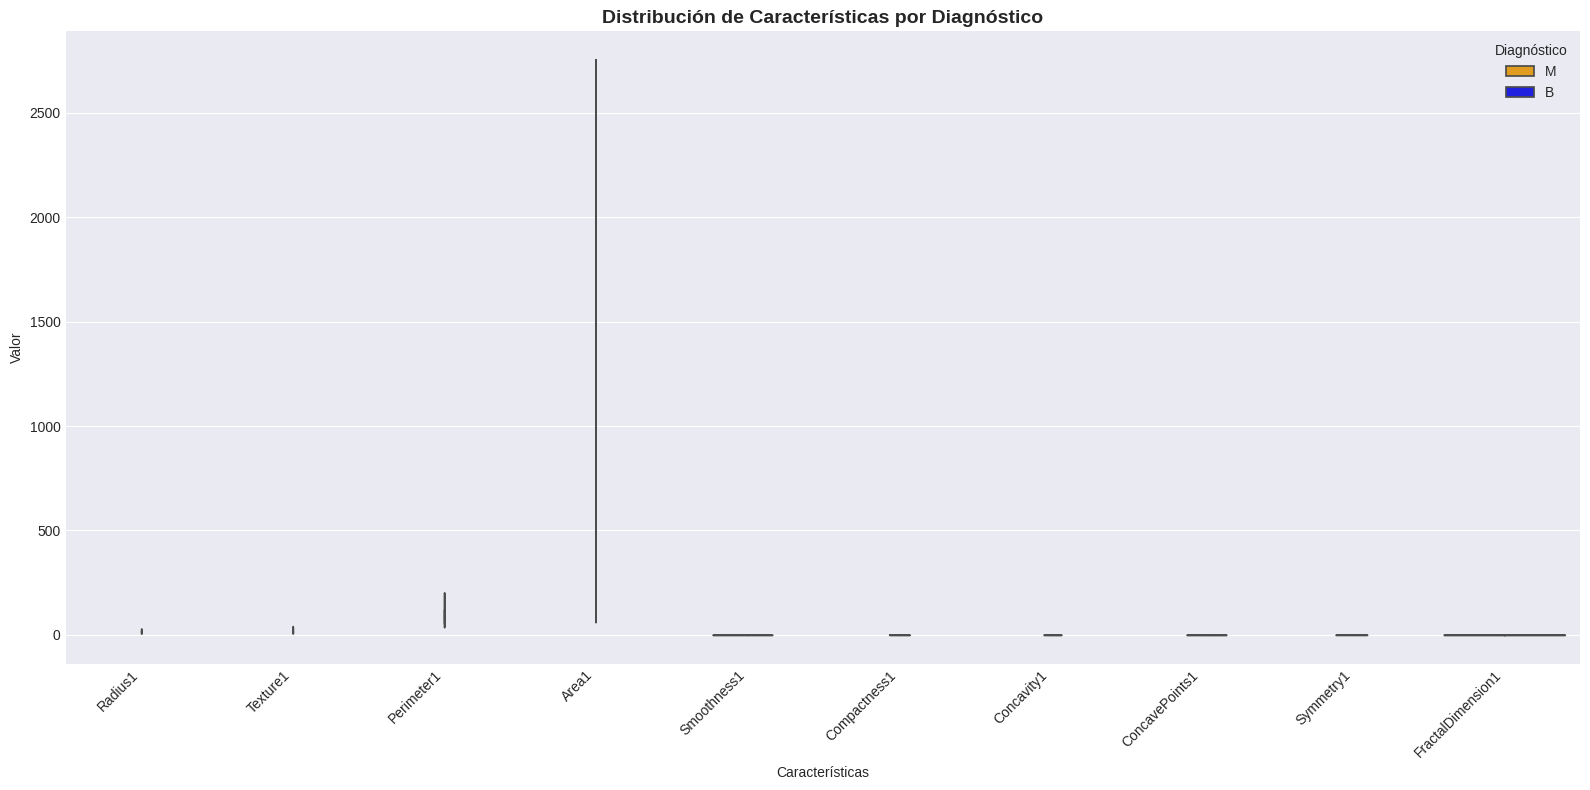


📦 12. ANÁLISIS DE OUTLIERS EN RADIUS1
--------------------------------------------------


<Figure size 1000x600 with 0 Axes>

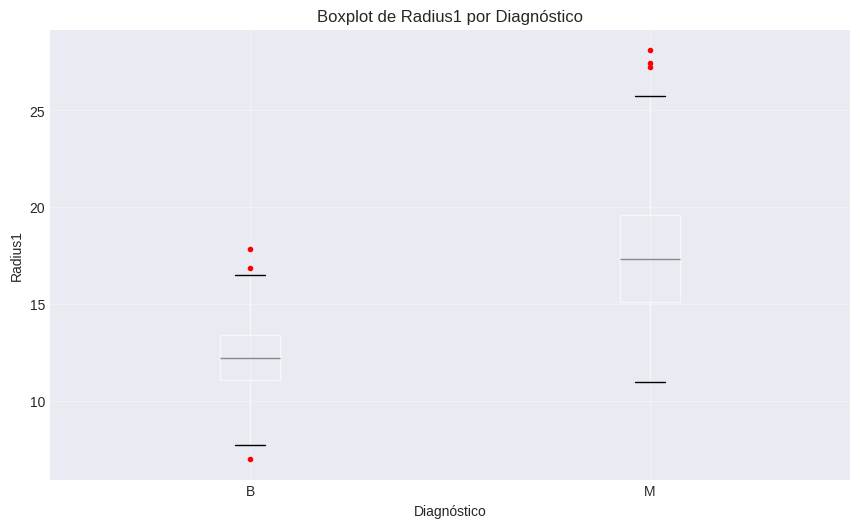


🔍 Detectando outliers con método IQR:

📊 Diagnóstico B:
   Q1: 11.0800, Q3: 13.3700, IQR: 2.2900
   Rango normal: [7.6450, 16.8050]
   Outliers encontrados: 3

📊 Diagnóstico M:
   Q1: 15.0750, Q3: 19.5900, IQR: 4.5150
   Rango normal: [8.3025, 26.3625]
   Outliers encontrados: 3

✅ Outliers eliminados:
   Registros originales: 569
   Registros sin outliers: 563
   Eliminados: 6

🔗 13. MATRIZ DE CORRELACIÓN
--------------------------------------------------


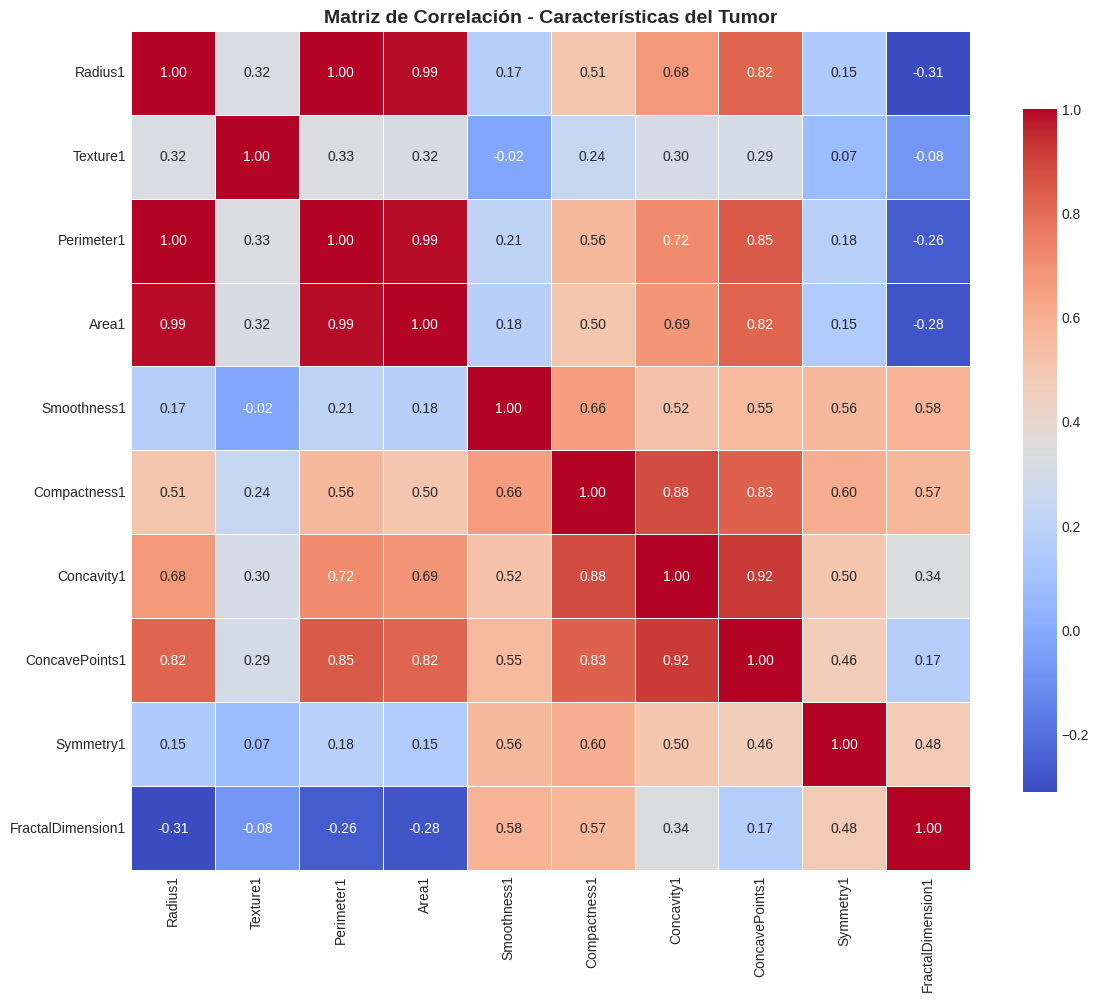


📊 Correlaciones más fuertes (>0.9 o <-0.9):
 Feature 1      Feature 2  Correlación
   Radius1     Perimeter1     0.997855
   Radius1          Area1     0.987357
Perimeter1          Area1     0.986507
Concavity1 ConcavePoints1     0.921391

📊 14. OTROS GRÁFICOS PARA ENTENDER MEJOR LOS DATOS
--------------------------------------------------


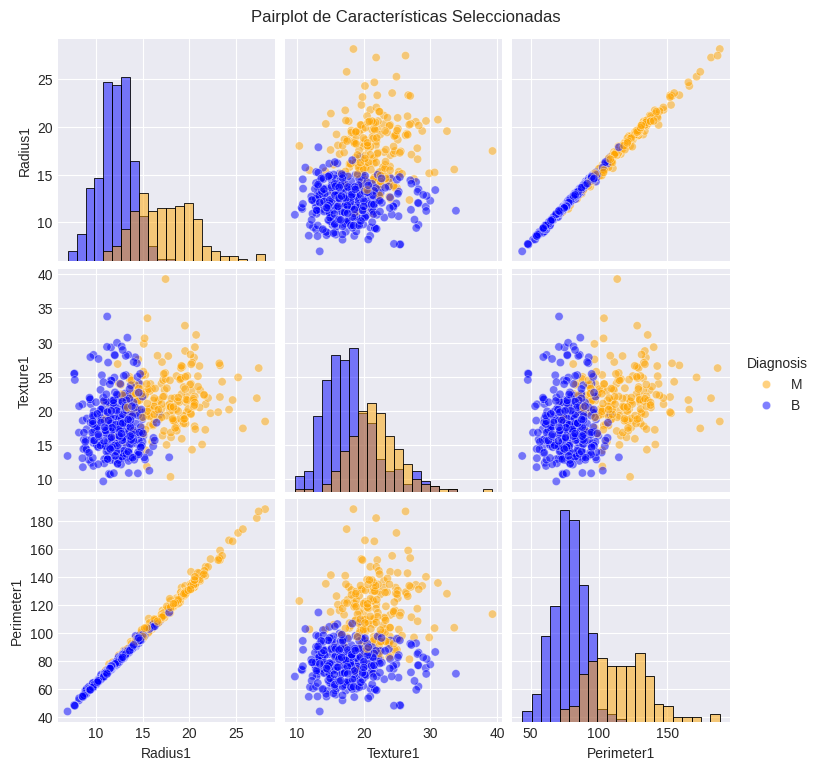

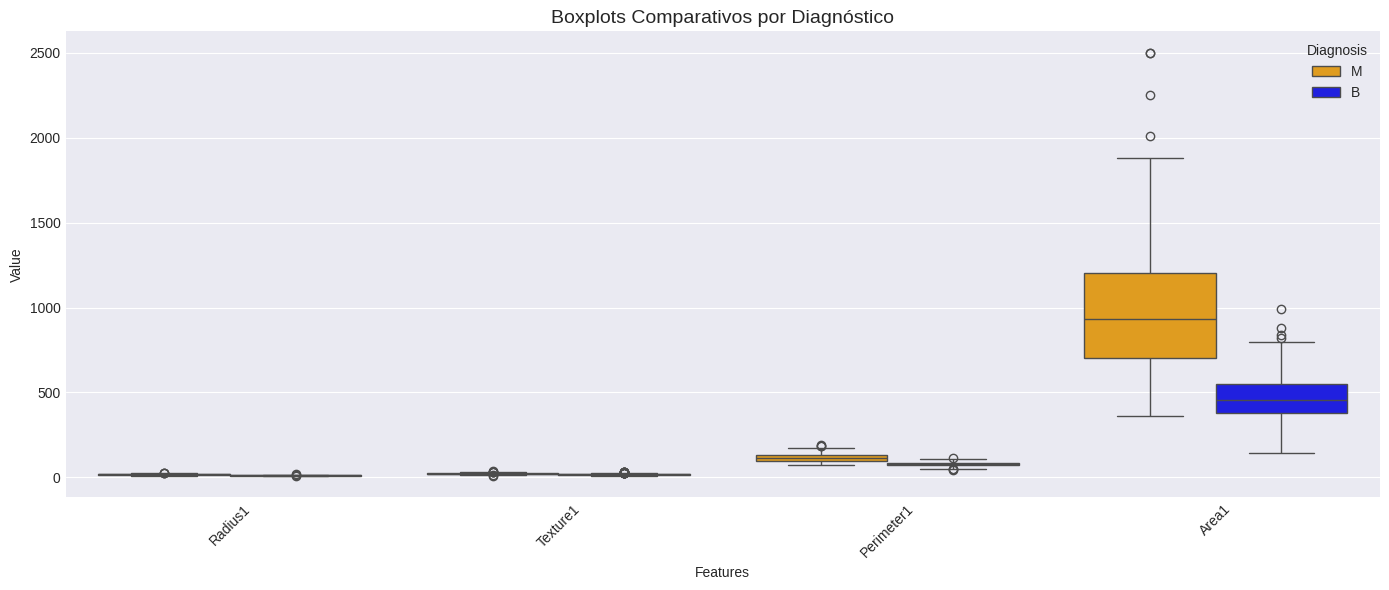

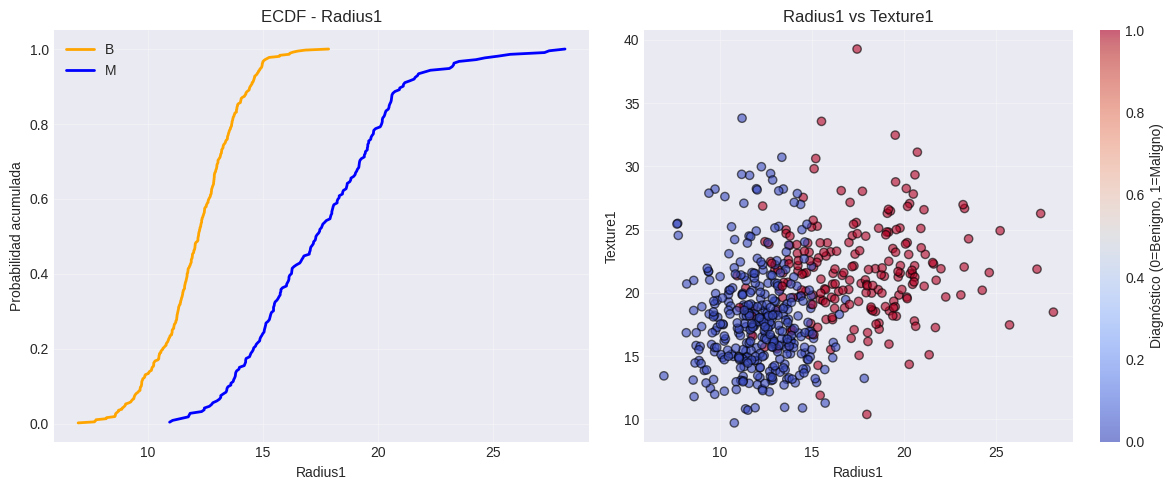


✅ ANÁLISIS COMPLETADO EXITOSAMENTE

📊 Resumen del dataset:
   - Total registros: 569
   - Total características: 30
   - Diagnósticos: B=357 (Benigno), M=212 (Maligno)

📈 Normalización: 30 características normalizadas
📦 Outliers en Radius1: 6 eliminados


In [5]:
# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("="*70)
print("ANÁLISIS DE DATOS - BREAST CANCER WISCONSIN")
print("="*70)

# ============================================
# 1. LEER DATOS DESDE PÁGINA WEB
# ============================================

print("\n📥 1. CARGANDO DATOS...")
print("-" * 50)

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# Crear DataFrame combinado
df = pd.concat([X, y], axis=1)

print(f"✅ Datos cargados correctamente")
print(f"   Dimensiones: {df.shape}")
print(f"   Filas: {df.shape[0]:,}, Columnas: {df.shape[1]}")

# ============================================
# 2. RENOMBRAR COLUMNAS A PASCALCASE
# ============================================

print("\n📝 2. RENOMBRANDO COLUMNAS A PASCALCASE...")
print("-" * 50)

# Función para convertir a PascalCase
def to_pascal_case(col_name):
    # Reemplazar guiones bajos y capitalizar cada palabra
    words = col_name.split('_')
    return ''.join(word.capitalize() for word in words)

# Aplicar a todas las columnas excepto Diagnosis
new_columns = {}
for col in df.columns:
    if col != 'Diagnosis':
        # Mantener los números al final (Radius1, Radius2, etc.)
        base_name = col.split('_')[0] if '_' in col else col
        number = col.split('_')[-1] if '_' in col and col.split('_')[-1].isdigit() else ''
        if number and number.isdigit():
            new_columns[col] = base_name.capitalize() + number
        else:
            new_columns[col] = to_pascal_case(col)
    else:
        new_columns[col] = col

df.rename(columns=new_columns, inplace=True)

print("✅ Columnas renombradas (primeras 15):")
print(list(df.columns)[:15])

# ============================================
# 3. INFORMACIÓN DEL DATAFRAME
# ============================================

print("\n📊 3. INFORMACIÓN DEL DATAFRAME")
print("-" * 50)

print("\n📌 head() - Primeras 5 filas:")
print(df.head())

print("\n📌 tail() - Últimas 5 filas:")
print(df.tail())

print("\n📌 describe() - Estadísticas descriptivas:")
print(df.describe().round(4))

print("\n📌 info() - Información general:")
print(df.info())

# ============================================
# 4. VALORES NULOS
# ============================================

print("\n🔍 4. ANÁLISIS DE VALORES NULOS")
print("-" * 50)

nulos = df.isnull().sum()
print("Valores nulos por columna:")
if any(nulos > 0):
    print(nulos[nulos > 0])
else:
    print("✅ No hay valores nulos en el dataset")

print("\n💡 Estrategia para valores nulos:")
print("   Si hubieran valores nulos, se podría:")
print("   - Eliminar filas con nulos (si son pocos)")
print("   - Imputar con la media/mediana de la columna")

# ============================================
# 5. VALORES ÚNICOS EN TARGET
# ============================================

print("\n🎯 5. VALORES ÚNICOS EN DIAGNOSIS")
print("-" * 50)

diagnosis_unique = df['Diagnosis'].unique()
print(f"Valores únicos: {diagnosis_unique}")
print(f"  B = Benigno (Benign)")
print(f"  M = Maligno (Malignant)")

# ============================================
# 6. COUNTPLOT CON SEABORN
# ============================================

print("\n📊 6. DISTRIBUCIÓN DE DIAGNÓSTICOS")
print("-" * 50)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Diagnosis', palette=['#3498db', '#e74c3c'])
plt.title('Distribución de Diagnósticos', fontsize=14, fontweight='bold')
plt.xlabel('Diagnóstico (B=Benigno, M=Maligno)')
plt.ylabel('Cantidad de casos')

# Agregar valores en las barras
for i, v in enumerate(df['Diagnosis'].value_counts().values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')

plt.show()

# Conteo
conteo = df['Diagnosis'].value_counts()
print(f"Benignos (B): {conteo.get('B', 0)}")
print(f"Malignos (M): {conteo.get('M', 0)}")

# ============================================
# 7. COLUMNA DIAGNOSIS NUMÉRICA
# ============================================

print("\n🔢 7. CREANDO COLUMNA DiagnosisNumeric")
print("-" * 50)

df['DiagnosisNumeric'] = df['Diagnosis'].map({'B': 0, 'M': 1})
print("Primeras 5 filas con DiagnosisNumeric:")
print(df[['Diagnosis', 'DiagnosisNumeric']].head())

# ============================================
# 8. NORMALIZACIÓN DE COLUMNAS
# ============================================

print("\n📈 8. NORMALIZACIÓN DE CARACTERÍSTICAS")
print("-" * 50)

# Seleccionar solo columnas numéricas (excluir Diagnosis y DiagnosisNumeric)
feature_cols = [col for col in df.columns if col not in ['Diagnosis', 'DiagnosisNumeric']]

# Crear DataFrame normalizado
df_normalized = df.copy()

print(f"Normalizando {len(feature_cols)} características...")

for col in feature_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()
    # Crear la columna normalizada
    normalized_col_name = col + '_Normalized'
    df_normalized[normalized_col_name] = (df[col] - mean_val) / std_val
    print(f"  ✓ {col} → {normalized_col_name}")

print(f"\n✅ Normalización completada")
print(f"   Total columnas ahora: {len(df_normalized.columns)}")
print(f"   Columnas originales: {len(feature_cols)}")
print(f"   Columnas normalizadas agregadas: {len(feature_cols)}")

# Mostrar ejemplo con una columna que sabemos que existe
print("\n📊 Ejemplo - Radius1 original vs normalizado:")
if 'Radius1' in df_normalized.columns and 'Radius1_Normalized' in df_normalized.columns:
    print(df_normalized[['Radius1', 'Radius1_Normalized']].head().round(6))
else:
    print("⚠️ No se encontró Radius1, mostrando primeras columnas disponibles:")
    available_cols = [col for col in df_normalized.columns if 'Radius' in col][:4]
    print(df_normalized[available_cols].head().round(6))

# ============================================
# 9. AGRUPAR CARACTERÍSTICAS SIMILARES
# ============================================

print("\n📊 9. AGRUPANDO CARACTERÍSTICAS SIMILARES")
print("-" * 50)

# Encontrar todas las características base (Radius, Texture, etc.)
bases = set()
for col in feature_cols:
    match = re.match(r'^([A-Za-z]+)', col)
    if match:
        bases.add(match.group(1))

print(f"Características base encontradas: {sorted(bases)}")

# Calcular promedios para cada grupo
print("\n📊 Promedios por grupo de características (primeras 5 filas):")
for base in sorted(bases)[:5]:  # Mostrar solo primeros 5 grupos
    group_cols = [col for col in feature_cols if col.startswith(base)]
    if group_cols:
        group_mean = df[group_cols].mean(axis=1)
        print(f"\n{base} (promedio de {len(group_cols)} columnas):")
        print(group_mean.head().round(4))

# ============================================
# 10. HISTOGRAMA RADIUS1 POR DIAGNÓSTICO
# ============================================

print("\n📊 10. HISTOGRAMA DE RADIUS1 POR DIAGNÓSTICO")
print("-" * 50)

plt.figure(figsize=(12, 6))

# Histograma para Benignos
plt.subplot(1, 2, 1)
benign_data = df[df['Diagnosis'] == 'B']['Radius1']
plt.hist(benign_data, bins=20, alpha=0.7, color='orange', edgecolor='black', label='Benigno (B)')
plt.axvline(benign_data.mean(), color='darkorange', linestyle='--', linewidth=2,
            label=f'Media: {benign_data.mean():.2f}')
plt.title('Distribución de Radius1 - Benignos', fontsize=12)
plt.xlabel('Radius1')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)

# Histograma para Malignos
plt.subplot(1, 2, 2)
malign_data = df[df['Diagnosis'] == 'M']['Radius1']
plt.hist(malign_data, bins=20, alpha=0.7, color='blue', edgecolor='black', label='Maligno (M)')
plt.axvline(malign_data.mean(), color='darkblue', linestyle='--', linewidth=2,
            label=f'Media: {malign_data.mean():.2f}')
plt.title('Distribución de Radius1 - Malignos', fontsize=12)
plt.xlabel('Radius1')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas comparativas
print("\n📊 Estadísticas comparativas de Radius1:")
print(f"Benignos  - Media: {benign_data.mean():.4f}, Std: {benign_data.std():.4f}")
print(f"Malignos  - Media: {malign_data.mean():.4f}, Std: {malign_data.std():.4f}")

# ============================================
# 11. GRÁFICOS DE VIOLÍN MÚLTIPLES
# ============================================

print("\n🎻 11. GRÁFICOS DE VIOLÍN PARA CARACTERÍSTICAS IMPORTANTES")
print("-" * 50)

# Seleccionar características para violin plot (versión 1 de cada característica)
violin_features = ['Radius1', 'Texture1', 'Perimeter1', 'Area1',
                   'Smoothness1', 'Compactness1', 'Concavity1',
                   'ConcavePoints1', 'Symmetry1', 'FractalDimension1']

# Filtrar solo las que existen
violin_features = [f for f in violin_features if f in df.columns]

# Preparar datos para violin plot
df_violin = pd.melt(df[['Diagnosis'] + violin_features],
                    id_vars='Diagnosis',
                    var_name='Features',
                    value_name='Value')

plt.figure(figsize=(16, 8))
sns.violinplot(x='Features', y='Value', hue='Diagnosis', data=df_violin,
               split=True, inner='quart', palette=['orange', 'blue'])
plt.title('Distribución de Características por Diagnóstico', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Características')
plt.ylabel('Valor')
plt.legend(title='Diagnóstico')
plt.tight_layout()
plt.show()

# ============================================
# 12. DETECCIÓN Y ELIMINACIÓN DE OUTLIERS (RADIUS1)
# ============================================

print("\n📦 12. ANÁLISIS DE OUTLIERS EN RADIUS1")
print("-" * 50)

# Boxplot para visualizar outliers
plt.figure(figsize=(10, 6))
df.boxplot(column="Radius1", by='Diagnosis', sym='r.', figsize=(10, 6))
plt.title('Boxplot de Radius1 por Diagnóstico')
plt.suptitle('')
plt.xlabel('Diagnóstico')
plt.ylabel('Radius1')
plt.grid(True, alpha=0.3)
plt.show()

# Detectar outliers usando IQR
print("\n🔍 Detectando outliers con método IQR:")

outliers_info = {}
outliers_indices = []

for diagnosis in ['B', 'M']:
    data = df[df['Diagnosis'] == diagnosis]['Radius1']
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Encontrar outliers
    outliers_mask = (data < lower_bound) | (data > upper_bound)
    outliers = data[outliers_mask]
    outliers_indices.extend(data[outliers_mask].index.tolist())

    outliers_info[diagnosis] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outliers_count': len(outliers)
    }

    print(f"\n📊 Diagnóstico {diagnosis}:")
    print(f"   Q1: {Q1:.4f}, Q3: {Q3:.4f}, IQR: {IQR:.4f}")
    print(f"   Rango normal: [{lower_bound:.4f}, {upper_bound:.4f}]")
    print(f"   Outliers encontrados: {len(outliers)}")

# Eliminar outliers
df_no_outliers = df.copy()
df_no_outliers = df_no_outliers.drop(index=outliers_indices)

print(f"\n✅ Outliers eliminados:")
print(f"   Registros originales: {len(df)}")
print(f"   Registros sin outliers: {len(df_no_outliers)}")
print(f"   Eliminados: {len(df) - len(df_no_outliers)}")

# ============================================
# 13. MATRIZ DE CORRELACIÓN
# ============================================

print("\n🔗 13. MATRIZ DE CORRELACIÓN")
print("-" * 50)

# Seleccionar características para correlación (versión 1 de cada una)
corr_features = ['Radius1', 'Texture1', 'Perimeter1', 'Area1',
                 'Smoothness1', 'Compactness1', 'Concavity1',
                 'ConcavePoints1', 'Symmetry1', 'FractalDimension1']

# Filtrar solo las que existen
corr_features = [f for f in corr_features if f in df.columns]

# Calcular matriz de correlación
corr_matrix = df[corr_features].corr()

# Visualizar con heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Características del Tumor', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlaciones más fuertes
print("\n📊 Correlaciones más fuertes (>0.9 o <-0.9):")
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.9:
            strong_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlación': corr_value
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr)
    print(strong_corr_df.to_string(index=False))
else:
    print("No hay correlaciones extremadamente fuertes")

# ============================================
# 14. OTROS GRÁFICOS ÚTILES
# ============================================

print("\n📊 14. OTROS GRÁFICOS PARA ENTENDER MEJOR LOS DATOS")
print("-" * 50)

# 1. Pairplot de características seleccionadas
selected_features = ['Radius1', 'Texture1', 'Perimeter1', 'Diagnosis']
sns.pairplot(df[selected_features], hue='Diagnosis', palette=['orange', 'blue'],
             diag_kind='hist', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot de Características Seleccionadas', y=1.02)
plt.show()

# 2. Boxplots comparativos
plt.figure(figsize=(14, 6))
features_to_plot = ['Radius1', 'Texture1', 'Perimeter1', 'Area1']
df_box = pd.melt(df[['Diagnosis'] + features_to_plot], id_vars='Diagnosis',
                 var_name='Features', value_name='Value')
sns.boxplot(x='Features', y='Value', hue='Diagnosis', data=df_box, palette=['orange', 'blue'])
plt.title('Boxplots Comparativos por Diagnóstico', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Distribución acumulada (ECDF)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for diagnosis, color in [('B', 'orange'), ('M', 'blue')]:
    data = df[df['Diagnosis'] == diagnosis]['Radius1'].sort_values()
    ecdf = np.arange(1, len(data)+1) / len(data)
    plt.plot(data, ecdf, label=f'{diagnosis}', color=color, linewidth=2)
plt.title('ECDF - Radius1')
plt.xlabel('Radius1')
plt.ylabel('Probabilidad acumulada')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Scatter plot con dos características
plt.subplot(1, 2, 2)
scatter = plt.scatter(df['Radius1'], df['Texture1'],
                      c=df['DiagnosisNumeric'], cmap='coolwarm', alpha=0.6, edgecolors='black')
plt.colorbar(scatter, label='Diagnóstico (0=Benigno, 1=Maligno)')
plt.title('Radius1 vs Texture1')
plt.xlabel('Radius1')
plt.ylabel('Texture1')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# RESUMEN FINAL
# ============================================

print("\n" + "="*70)
print("✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("="*70)
print(f"\n📊 Resumen del dataset:")
print(f"   - Total registros: {df.shape[0]:,}")
print(f"   - Total características: {df.shape[1] - 2}")  # -2 por Diagnosis y DiagnosisNumeric
print(f"   - Diagnósticos: B={conteo.get('B', 0)} (Benigno), M={conteo.get('M', 0)} (Maligno)")
print(f"\n📈 Normalización: {len(feature_cols)} características normalizadas")
print(f"📦 Outliers en Radius1: {len(outliers_indices)} eliminados")
print("="*70)